<a href="https://colab.research.google.com/github/Dikshit47/salary-prediction-ML/blob/main/salary_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import Libraries

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

 Load Dataset

In [7]:
sal_data = pd.read_csv('/content/Salary Data.csv')

sal_data.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


Rename Columns

In [8]:
sal_data.columns = ['Age','Gender','Degree','Job_Title','Experience_Year','Salary']

sal_data.head()

,Age,Gender,Degree,Job_Title,Experience_Year,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


Data Cleaning

In [9]:
sal_data = sal_data.drop_duplicates()

In [10]:
sal_data = sal_data.dropna()

sal_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 324 entries, 0 to 371
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Age              324 non-null    float64
 1   Gender           324 non-null    object 
 2   Degree           324 non-null    object 
 3   Job_Title        324 non-null    object 
 4   Experience_Year  324 non-null    float64
 5   Salary           324 non-null    float64
dtypes: float64(3), object(3)
memory usage: 17.7+ KB


**Exploratory Data Analysist**

correlation

In [11]:
corr = sal_data[['Age','Experience_Year','Salary']].corr()


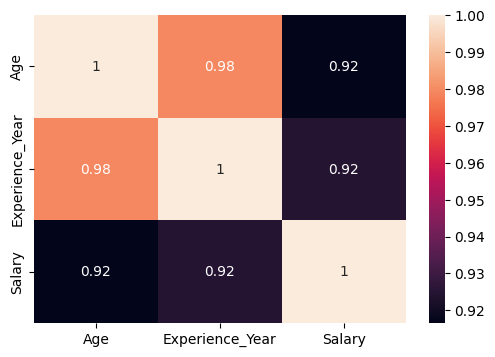

In [12]:
plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True)
plt.show()

Degree distribution

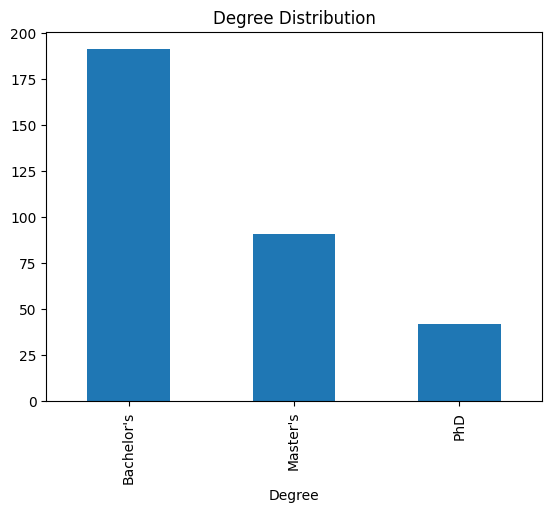

In [13]:
sal_data['Degree'].value_counts().plot(kind='bar')
plt.title("Degree Distribution")
plt.show()


Gender distribution

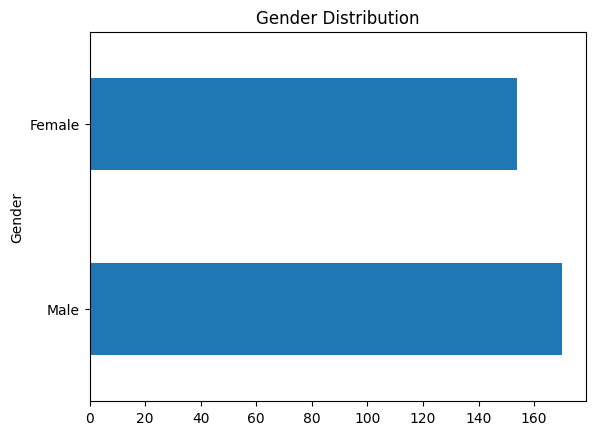

In [14]:
sal_data['Gender'].value_counts().plot(kind='barh')
plt.title("Gender Distribution")
plt.show()

 Age histogram

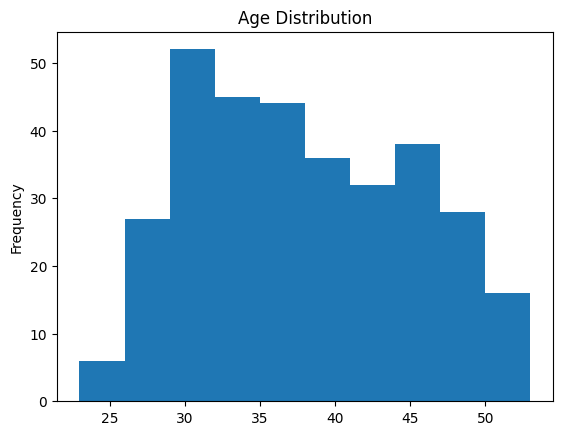

In [15]:
sal_data['Age'].plot(kind='hist')
plt.title("Age Distribution")
plt.show()


Encoding Categorical Data

In [16]:
encoder = LabelEncoder()

sal_data['Gender_Encode'] = encoder.fit_transform(sal_data['Gender'])
sal_data['Degree_Encode'] = encoder.fit_transform(sal_data['Degree'])
sal_data['Job_Title_Encode'] = encoder.fit_transform(sal_data['Job_Title'])

sal_data.head()

,Age,Gender,Degree,Job_Title,Experience_Year,Salary,Gender_Encode,Degree_Encode,Job_Title_Encode
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0,1,0,159
1,28.0,Female,Master's,Data Analyst,3.0,65000.0,0,1,17
2,45.0,Male,PhD,Senior Manager,15.0,150000.0,1,2,130
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0,0,0,101
4,52.0,Male,Master's,Director,20.0,200000.0,1,1,22


Feature Scaling

In [17]:
scaler = StandardScaler()

sal_data['Age_scaled'] = scaler.fit_transform(sal_data[['Age']])
sal_data['Experience_scaled'] = scaler.fit_transform(sal_data[['Experience_Year']])

Define Features and Target

In [18]:
X = sal_data[['Age_scaled','Gender_Encode','Degree_Encode','Job_Title_Encode','Experience_scaled']]
y = sal_data['Salary']

Train Test Split

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape)
print(X_test.shape)

(259, 5)
(65, 5)


Linear Regression Model

In [20]:
lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

 Decision Tree Regression

In [21]:
dt_model = DecisionTreeRegressor()

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

Random Forest Regression

In [22]:
rf_model = RandomForestRegressor()

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [23]:
pip install pickle


ERROR: Could not find a version that satisfies the requirement pickle (from versions: none)
ERROR: No matching distribution found for pickle


In [29]:
import pickle
pickle.dump(rf_model,open("salary_model.pkl","wb"))

In [30]:
from google.colab import files
files.download("salary_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 Model Evaluation Function

In [25]:
def evaluate_model(y_test, y_pred):

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)

    return r2, mae, rmse

Evaluate All Models

In [26]:
lr_result = evaluate_model(y_test, y_pred_lr)
dt_result = evaluate_model(y_test, y_pred_dt)
rf_result = evaluate_model(y_test, y_pred_rf)

Model Comparison

In [27]:
results = pd.DataFrame({

'Model': ['Linear Regression','Decision Tree','Random Forest'],

'R2 Score': [lr_result[0], dt_result[0], rf_result[0]],

'MAE': [lr_result[1], dt_result[1], rf_result[1]],

'RMSE': [lr_result[2], dt_result[2], rf_result[2]]

})

print(results)

               Model  R2 Score           MAE          RMSE
0  Linear Regression  0.891123  10570.786401  14344.132449
1      Decision Tree  0.840845  11846.153846  17342.699639
2      Random Forest  0.913575   9208.838205  12779.874511


Salary Prediction Example

In [28]:
age = scaler.transform([[49]])[0][0]
exp = scaler.transform([[15]])[0][0]

gender = 0
degree = 2
job = 22

prediction = lr_model.predict([[age, gender, degree, job, exp]])

print("Predicted Salary:", prediction[0])

Predicted Salary: 249925.15052544305


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
